# Audit Module Demo

Demonstrates `BiasAuditor` (pre-model) and `FairnessAuditor` (post-model) using the Adult dataset.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from skfair.datasets import load_adult
from skfair.audit import BiasAuditor, FairnessAuditor

X, y = load_adult(preprocessed=True)

## 1. Pre-model Bias Auditing (BiasAuditor)

Analyse data-level disparities before training any model.

In [2]:
bias = BiasAuditor(X, y, sens_attr="sex", priv_group=1, pos_label=1)

# Group proportions table
bias.group_proportions()

,count,proportion
sex,,
1,21790,0.669205
0,10771,0.330795


In [3]:
# Target rate by group
bias.target_rate_by_group()

,count,positive_rate
sex,,
0,10771,0.109461
1,21790,0.305737


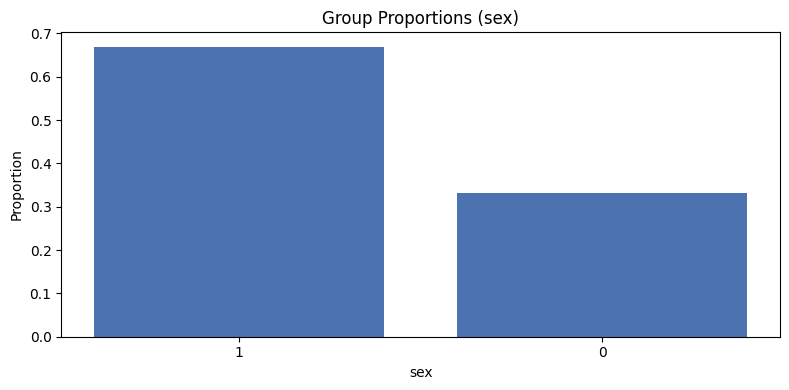

In [4]:
# Plot: group proportions
bias.plot_group_proportions();

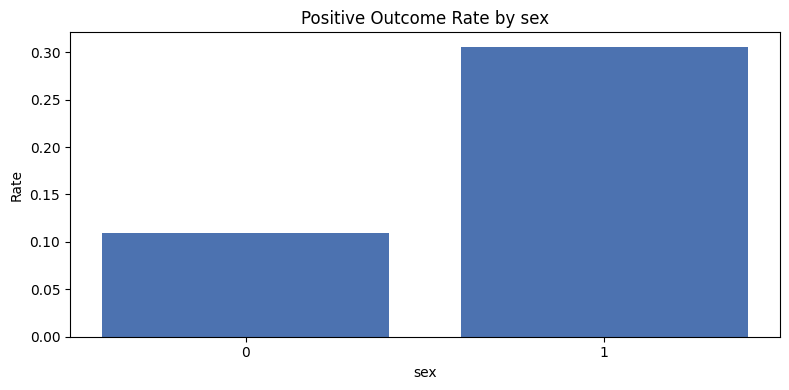

In [5]:
# Plot: positive outcome rate per group
bias.plot_target_rates();

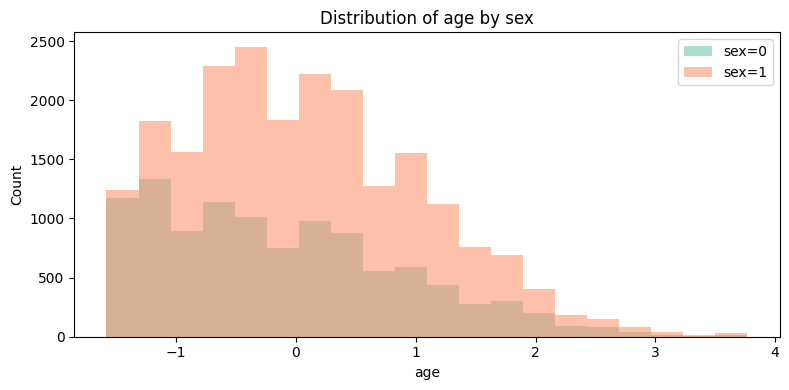

In [6]:
# Plot: feature distribution split by sensitive attribute
bias.plot_feature_distribution("age");

## 2. Train a simple model

Quick logistic regression to get predictions for the fairness audit.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

sens_test = X_test["sex"].values

## 3. Post-model Fairness Auditing (FairnessAuditor)

Audit prediction-level fairness metrics.

In [8]:
auditor = FairnessAuditor(y_test, y_pred, sens_test, priv_group=1, pos_label=1)

# Per-group performance table
auditor.performance_by_group()

,unprivileged,privileged
Accuracy,0.929353,0.815525
TPR,0.558659,0.616851
FPR,0.023935,0.097902
TNR,0.976065,0.902098
FNR,0.441341,0.383149


In [9]:
# All fairness metrics as a DataFrame (use freely for custom analysis)
auditor.fairness_metrics()

,value
Disparate Impact,0.328015
Statistical Parity Diff,-0.171627
Equal Opportunity Diff,-0.058191
Equal Opportunity Ratio,0.905664
Average Odds Diff,-0.066079
TNR Difference,0.073967
FNR Difference,0.058191
Predictive Equality,0.244481
Accuracy Parity,1.139576


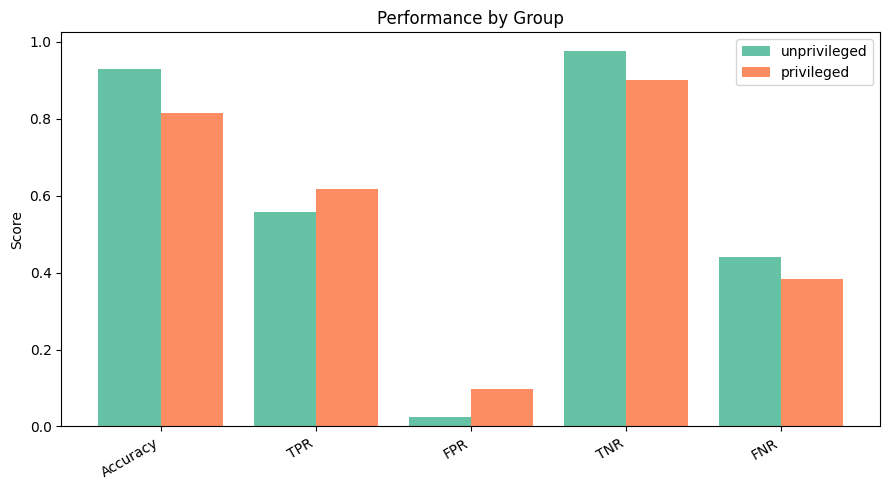

In [10]:
# Plot: per-group performance (grouped bars)
auditor.plot_performance_by_group();

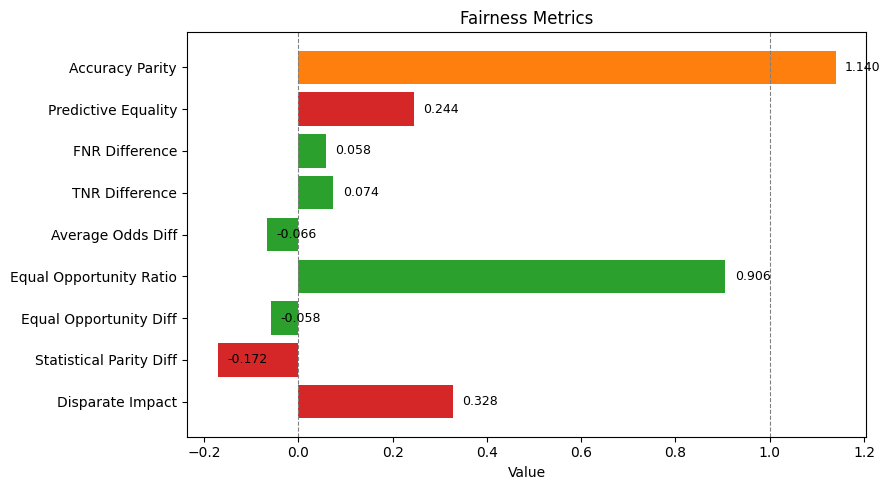

In [11]:
# Plot: fairness metrics with colour-coded thresholds (green/orange/red)
auditor.plot_fairness_metrics();

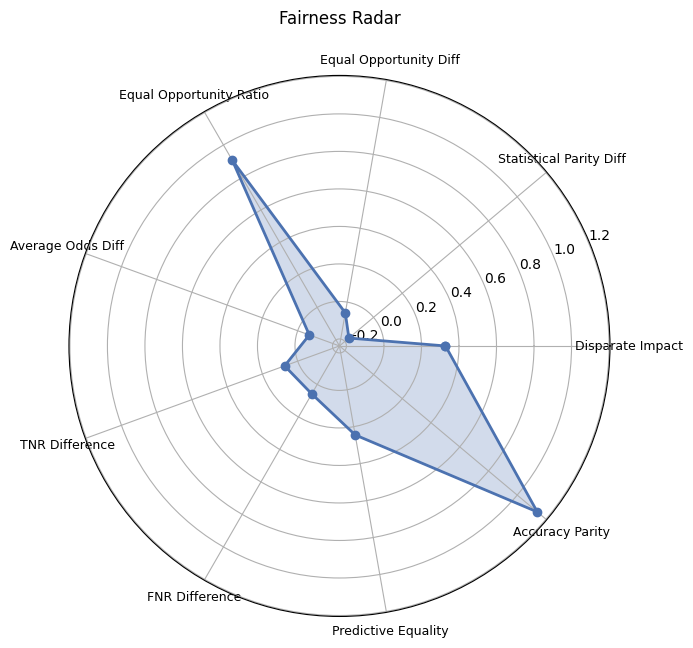

In [12]:
# Plot: radar chart of all fairness metrics
auditor.plot_fairness_radar();

## 4. Full Summary (all plots at once)

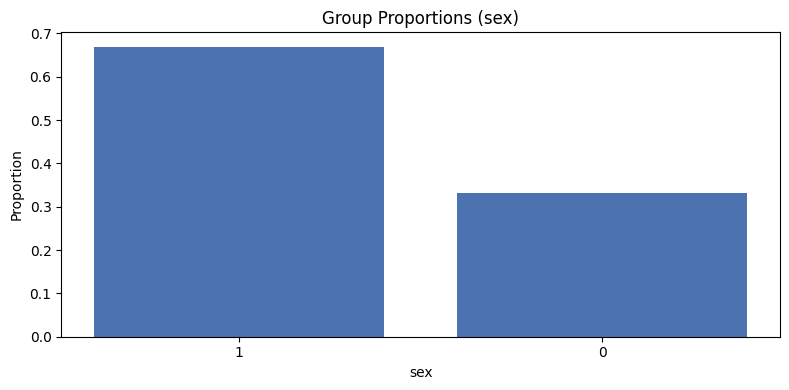

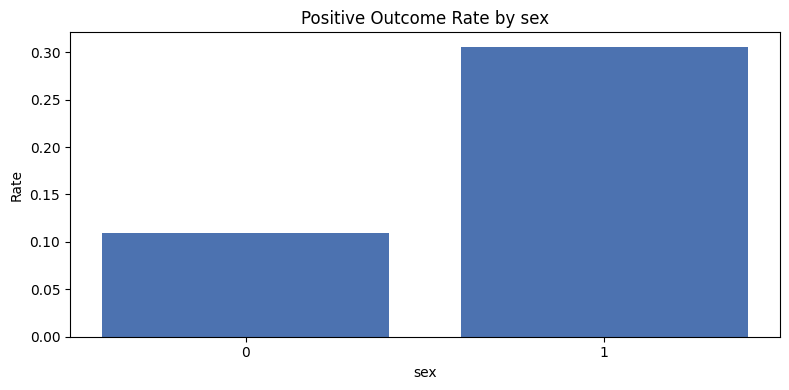

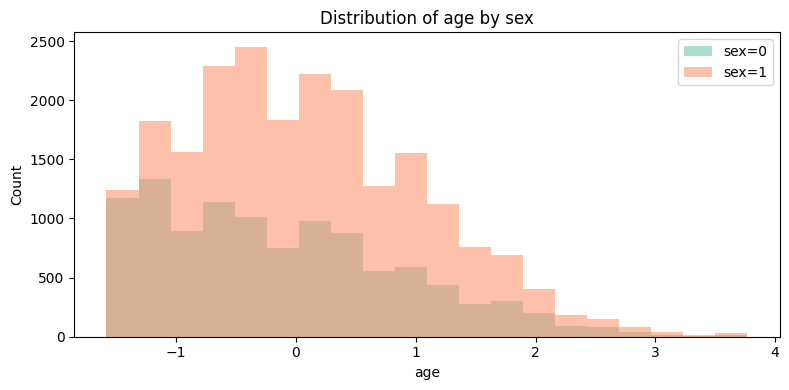

In [13]:
# Pre-model: all bias plots (proportions, target rates, feature distributions)
bias.plot_summary(features=["age"]);

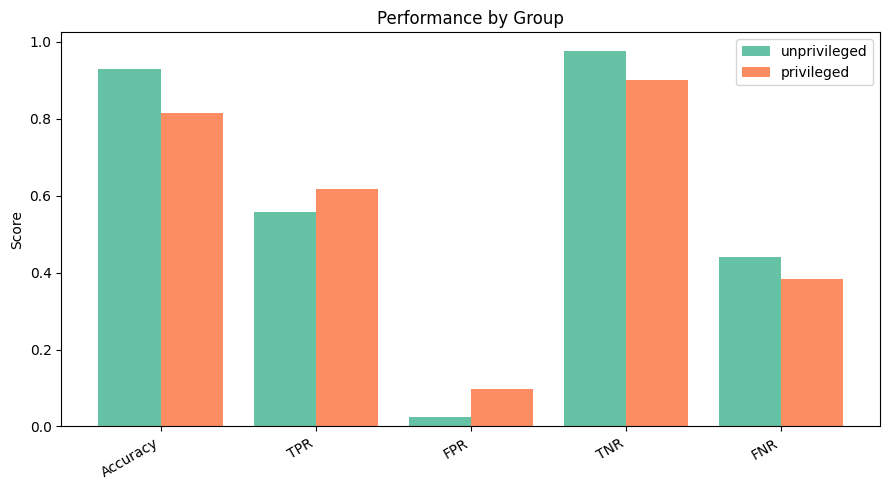

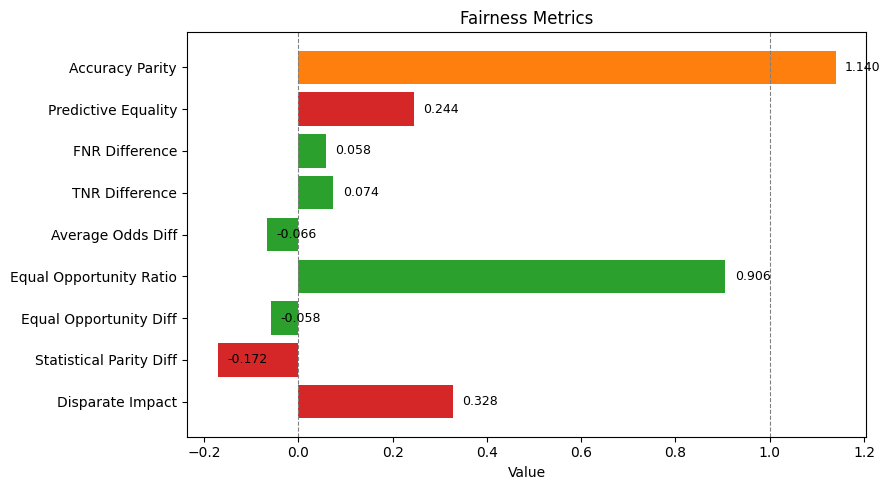

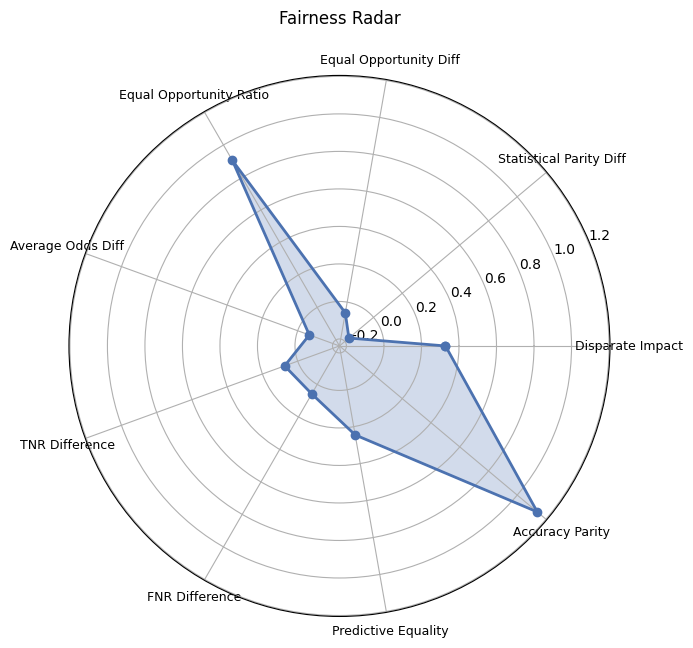

In [14]:
# Post-model: all fairness plots (grouped bars, metric bars, radar)
auditor.plot_summary();